# Calcolo degli spettri di potenza su tutti i file del dataset

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from lib.readwav import readwav
import ipywidgets as widgets
from numpy.lib.stride_tricks import sliding_window_view

In [9]:
%matplotlib widget
plt.close('all')

NOTA: non stiamo tagliando ne l'attacco ne la coda. Lo step potrebbe essere calcolato meglio in base alla durata del campione, ma per ora è un valore fisso.

In [10]:
# trova i file disponibili
available_files = [f for f in os.listdir('Data_organ') if f.endswith('.wav')]

available_files = sorted(available_files, key=lambda x: int(x.split("_")[1].split(".")[0]), reverse=False)

available_files =  available_files

print("File disponibili:")
for f in available_files:
    print(f)

File disponibili:
note_1.wav
note_2.wav
note_3.wav
note_4.wav
note_5.wav
note_6.wav
note_7.wav
note_8.wav
note_9.wav
note_10.wav
note_11.wav
note_12.wav
note_13.wav
note_14.wav
note_15.wav
note_16.wav
note_17.wav
note_18.wav
note_19.wav
note_20.wav
note_21.wav
note_22.wav
note_23.wav
note_24.wav
note_25.wav
note_26.wav
note_27.wav
note_28.wav
note_29.wav
note_30.wav
note_31.wav
note_32.wav
note_33.wav
note_34.wav
note_35.wav
note_36.wav
note_37.wav
note_38.wav
note_39.wav
note_40.wav
note_41.wav
note_42.wav
note_43.wav
note_44.wav
note_45.wav
note_46.wav
note_47.wav
note_48.wav
note_49.wav
note_50.wav
note_51.wav
note_52.wav
note_53.wav
note_54.wav
note_55.wav
note_56.wav
note_57.wav
note_58.wav
note_59.wav
note_60.wav
note_61.wav
note_62.wav
note_63.wav
note_64.wav
note_65.wav
note_66.wav
note_67.wav
note_68.wav
note_69.wav
note_70.wav
note_71.wav
note_72.wav
note_73.wav
note_74.wav
note_75.wav
note_76.wav
note_77.wav
note_78.wav
note_79.wav
note_80.wav
note_81.wav
note_82.wav
note_83

In [11]:
def avg_spectrum_gaussian(
    signal,
    fs,
    sigma_samples,
    step_size,
    span_sigma=3.0,     # quante sigma includere nella finestra. Numeri bassi riducono la risoluzione in frequenza, numeri alti aumentano il rumore
    n_fft=None,
    chunk_size=256
):
    window_size = int(np.ceil(2 * span_sigma * sigma_samples))
    window_size = max(window_size, 8)

    if window_size > len(signal):
        raise ValueError("window_size troppo grande rispetto al segnale")

    if window_size % 2 != 0:
        window_size += 1

    if n_fft is None:
        n_fft = window_size
    if n_fft < window_size:
        raise ValueError("n_fft deve essere >= window_size")

    # finestre scorrevoli
    frames = sliding_window_view(signal, window_size)[::step_size]
    n_windows = frames.shape[0]
    if n_windows == 0:
        raise ValueError("Nessuna finestra: riduci window_size o step_size")

    # gaussiana centrata con sigma scelto
    n = np.arange(window_size)
    c = (window_size - 1) / 2.0
    g = np.exp(-0.5 * ((n - c) / sigma_samples) ** 2)

    # normalizzazione
    g /= np.sqrt(np.sum(g**2))

    # accumulo a blocchi
    acc = np.zeros(n_fft // 2 + 1, dtype=np.float64)

    for i in range(0, n_windows, chunk_size):
        chunk = frames[i:i + chunk_size] * g
        spec = np.abs(np.fft.rfft(chunk, n=n_fft, axis=-1)) ** 2
        acc += spec.sum(axis=0)

    avg_spectrum = acc / n_windows
    freqs = np.fft.rfftfreq(n_fft, d=1/fs)
    return freqs, avg_spectrum

In [12]:
num_periods = 5    # numero di periodi da includere nella singola finestra
step_size = 1000     # passo di scorrimento della finestra in campioni

avg_spectra = {}

for i, filename in enumerate(available_files):

    print(f"Processing file {i+1}/{len(available_files)}: {filename}")

    # carica il file e seleziona il canale
    rate, data = readwav(os.path.join('Data_organ', filename))
    channel1 = data[:,0]

    # definizioni utili
    n = np.arange(channel1.size)
    N = len(channel1)

    # stima periodo e calcolo della finestra gaussiana
    signal_peaks, _ = sp.signal.find_peaks(channel1[N//2-5000:N//2+5000], height=np.max(channel1)*0.1)
    differences = np.diff(signal_peaks)
    period = np.mean(differences) / rate
    window_size = int(num_periods * period * rate)

    step_size = window_size // 4

    try:
        # calcola spettro di potenza medio facendo scorrere la finestra gaussiana lungo il segnale
        freqs, avg_spectrum = avg_spectrum_gaussian(channel1, rate, window_size, step_size=step_size, span_sigma=5)
        avg_spectra[filename] = (freqs, avg_spectrum)
        
    except ValueError as e:
        print(f"Errore nel file {filename}: {e}")
        continue


Processing file 1/280: note_1.wav
Processing file 2/280: note_2.wav
Processing file 3/280: note_3.wav
Processing file 4/280: note_4.wav
Processing file 5/280: note_5.wav
Processing file 6/280: note_6.wav
Processing file 7/280: note_7.wav
Processing file 8/280: note_8.wav
Processing file 9/280: note_9.wav
Processing file 10/280: note_10.wav
Processing file 11/280: note_11.wav
Processing file 12/280: note_12.wav
Processing file 13/280: note_13.wav
Processing file 14/280: note_14.wav
Processing file 15/280: note_15.wav
Processing file 16/280: note_16.wav
Processing file 17/280: note_17.wav
Processing file 18/280: note_18.wav
Processing file 19/280: note_19.wav
Processing file 20/280: note_20.wav
Processing file 21/280: note_21.wav
Processing file 22/280: note_22.wav
Processing file 23/280: note_23.wav
Processing file 24/280: note_24.wav
Processing file 25/280: note_25.wav
Processing file 26/280: note_26.wav
Processing file 27/280: note_27.wav
Processing file 28/280: note_28.wav
Processing

Dropdown(description='Spettro:', options=('note_1.wav', 'note_2.wav', 'note_3.wav', 'note_4.wav', 'note_5.wav'…

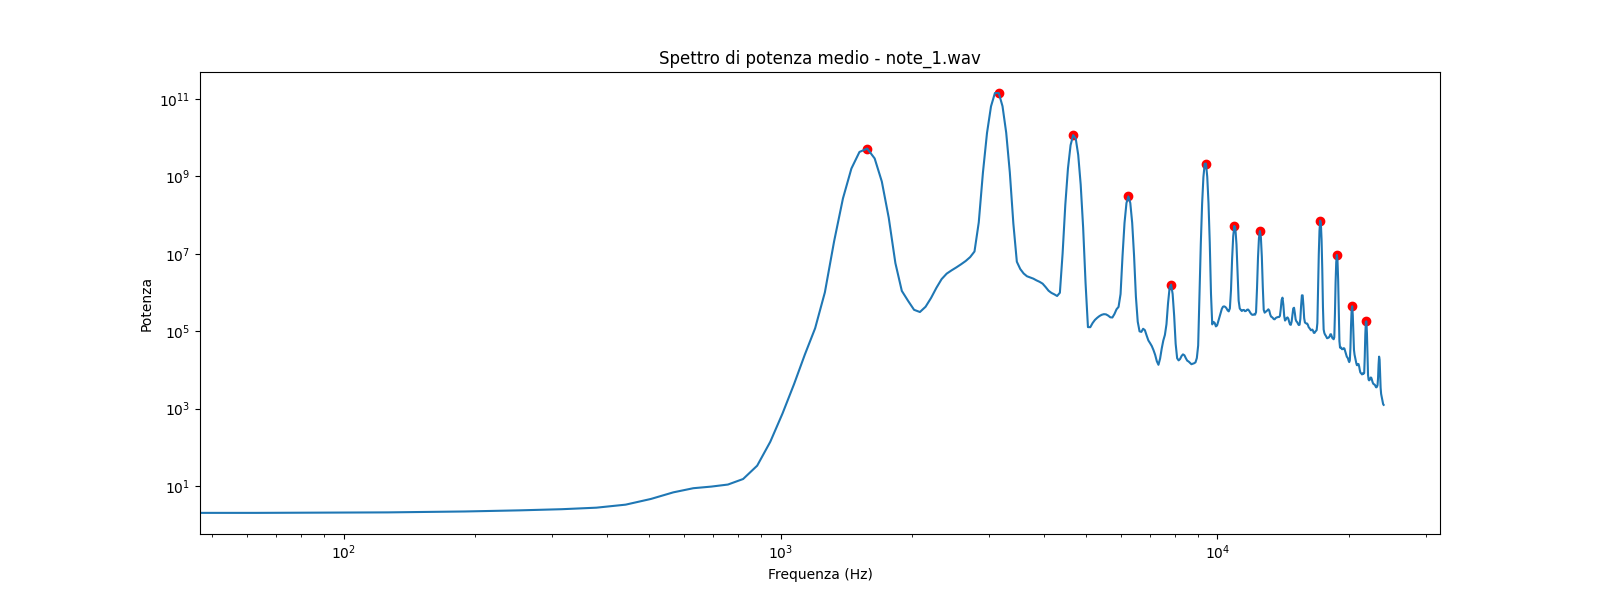

In [13]:
spectrum_selector = widgets.Dropdown(
    options=list(avg_spectra.keys()),
    description='Spettro:',
    disabled=False,
)

fig, ax = plt.subplots()
fig.set_size_inches(16, 6)
canvas = fig.canvas

def update_plot(change):
    filename = change['new']
    freqs, avg_spectrum = avg_spectra[filename]

    peaks,_ = sp.signal.find_peaks(np.log10(avg_spectrum), prominence=1)

    ax.clear()
    ax.plot(freqs, avg_spectrum)

    plt.scatter(freqs[peaks], avg_spectrum[peaks], color='red', label='Picchi')

    ax.set_title(f"Spettro di potenza medio - {filename}")
    ax.set_xlabel("Frequenza (Hz)")
    ax.set_ylabel("Potenza")
    ax.set_xscale('log')
    ax.set_yscale('log')

spectrum_selector.observe(update_plot, names='value')
display(spectrum_selector)
update_plot({'new': spectrum_selector.value})

In [14]:
# Salva i risultati in dati_processati/spettri_{num_periods_in_window}_periodi/{filename}_spectrum.npz
output_dir = f"dati_processati/spettri_{num_periods}_periodi"
os.makedirs(output_dir, exist_ok=True)
for filename, (freqs, avg_spectrum) in avg_spectra.items():
    np.savez(os.path.join(output_dir, f"{filename}_spectrum.npz"), freqs=freqs, avg_spectrum=avg_spectrum)